# Transfer Learning 기반의 CNN 모델 학습 - 과제

---

## 학습 개요

1. **학습 주제**
  - **전이 학습(Transfer Learning)**: 사전 학습된 모델의 가중치를 활용하여 새로운 데이터셋에 적응시키는 기법
  - **Linear Probing과 Fine-tuning**: 레이어 동결 전략을 통한 효율적인 모델 학습 방법
  - **학습률 스케줄러 및 옵티마이저**: 모델 수렴 속도와 성능을 최적화하는 하이퍼파라미터 조정 기법

2. **학습 목표**
  - 전이 학습의 핵심 개념을 이해하고, **Backbone과 Head의 역할**, **레이어 동결의 의미**, **Partial Fine-tuning의 의도**를 명확히 설명할 수 있다.
  - 사전 학습된 ResNet-18 모델을 Flowers102 데이터셋에 맞게 **적응(adaptation)**시키고, Linear Probing과 Partial Fine-tuning의 차이를 실습할 수 있다.
  - **데이터 크기, 도메인 차이, 학습률 설정**에 따른 전이 학습 성능 변화를 이해하고, 적절한 학습 전략을 선택할 수 있다.
  - 다양한 **Learning Rate Scheduler**(StepLR, ReduceLROnPlateau)와 **Optimizer**(SGD+Momentum, Adam)를 적용하고, 각각의 특성을 비교·분석할 수 있다.
  - 실험 결과를 **가설-결과-해석** 구조로 정리하여, 하이퍼파라미터 변경이 수렴/과적합/일반화에 미치는 영향을 설명할 수 있다.

3. **핵심 개념**
  - **전이 학습(Transfer Learning)**: 대규모 데이터셋(예: ImageNet)에서 사전 학습된 모델의 지식을 새로운 태스크에 재활용하는 기법. 적은 데이터로도 높은 성능을 달성할 수 있으며, 학습 시간을 크게 단축시킨다.
  - **Backbone과 Head**: Backbone은 특성 추출을 담당하는 사전 학습된 레이어들(conv layers)이며, Head는 태스크별 출력을 생성하는 최종 분류기(fc layer)를 의미한다.
  - **레이어 동결(Freezing)**: 특정 레이어의 `requires_grad=False`로 설정하여 해당 가중치를 학습 과정에서 업데이트하지 않는 기법. 사전 학습된 지식을 보존하고 학습 속도를 향상시킨다.
  - **Linear Probing**: Backbone을 완전히 동결하고 Head(분류기)만 학습하는 방식. 사전 학습된 특성 표현을 그대로 활용하여 새로운 태스크에 적응한다.
  - **Partial Fine-tuning**: Backbone의 일부(예: layer4)와 Head를 함께 학습하는 방식. 사전 학습 지식을 유지하면서도 목표 도메인에 맞춤 조정을 수행한다.
  - **Learning Rate Scheduler**: 학습 과정에서 학습률을 동적으로 조정하는 기법. StepLR(주기적 감소), ReduceLROnPlateau(성능 정체 시 감소) 등이 있다.
  - **Optimizer**: 손실 함수를 최소화하기 위한 가중치 업데이트 알고리즘. SGD+Momentum(관성 활용), Adam(적응적 학습률) 등이 대표적이다.

4. **선행 지식**
  - Python 기본 문법 및 PyTorch 기초 (텐서 연산, autograd, 모델 정의)
  - CNN 기본 개념 (convolution, pooling, activation function)
  - 지도 학습의 기본 흐름 (train/test split, loss, backpropagation)
  - (선택) ResNet 아키텍처의 기본 구조 이해

5. **실습↔과제 연결**
  - 실습에서 다뤘던 **전이 학습의 기본 흐름**과 **Linear Probing**을 출발점으로 사용합니다.
  - 과제에서는 **조건 변화(약한 변형)**로 Partial Fine-tuning(layer4 + fc 학습)을 추가하고, 다양한 Scheduler/Optimizer 조합을 실험하여 **성능 차이의 원인을 분석**합니다.

6. **Further Reading**
  - [Transfer Learning Guide (PyTorch Official)](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html): PyTorch 공식 전이 학습 튜토리얼로, Linear Probing과 Fine-tuning의 실무적 구현 방법을 단계별로 설명합니다.
  - [Understanding Learning Rate Schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate): PyTorch 공식 문서로, 다양한 스케줄러의 작동 원리와 사용법을 소개합니다.
  - [An Overview of Gradient Descent Optimization Algorithms](https://ruder.io/optimizing-gradient-descent/): SGD, Momentum, Adam 등 주요 옵티마이저의 수학적 원리와 장단점을 비교 분석합니다.
  - [How transferable are features in deep neural networks?](https://arxiv.org/abs/1411.1792): 전이 학습의 이론적 배경을 다룬 논문으로, 어떤 레이어가 일반적/특화된 특성을 학습하는지 설명합니다.

7. **Open-ended Mission**
  - **다양한 동결 전략 실험**: layer3만 학습, layer2+layer3+layer4 학습 등 다양한 레이어 조합을 시도하여 성능과 학습 속도를 비교하고, 최적 전략을 도출하기
  - **Data Augmentation 강화**: AutoAugment, RandAugment, CutMix 등 고급 증강 기법을 적용하여 과적합을 방지하고 일반화 성능을 향상시키기
  - **다른 사전 학습 모델 비교**: ResNet-50, EfficientNet, Vision Transformer 등 다양한 아키텍처로 전이 학습을 수행하여 모델별 특성과 성능 차이를 분석하기
  - **Hyperparameter Tuning**: Optuna, Ray Tune 등 자동 하이퍼파라미터 최적화 도구를 활용하여 최적의 학습률, 배치 크기, 스케줄러 조합을 탐색하기

## 과제 구성

1. **학습 방향**

- **실습 구성 방식**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현
  - 전이 학습의 핵심 개념(동결, Fine-tuning)을 코드로 체험
  - 실험 결과를 가설-결과-해석 구조로 분석

- **Required Package**

  ```
  numpy>=2.0.0
  matplotlib>=3.8.0
  tqdm>=4.66.0
  torch>=2.1.0
  torchvision>=0.16.0
  ```

- **Step 요약**
  - **Step 1 (약 25분)**: 데이터 준비 및 전처리 - Flowers102 데이터셋을 로드하고, 정규화 파라미터를 계산하여 학습/검증/테스트 데이터셋을 구성
  - **Step 2 (약 35분)**: Partial Fine-tuning 기반 모델 학습 - ResNet-18의 layer4와 fc를 학습시키고, 다양한 Optimizer/Scheduler 조합으로 성능을 비교 분석

2. **데이터셋 개요 및 저작권 정보**
  - **데이터셋 명**: Flowers102 Dataset
  - **데이터셋 개요**: 102종의 꽃 이미지로 구성된 데이터셋으로, 각 클래스당 40~258개의 샘플을 포함합니다. Train(1020), Validation(1020), Test(6149) split으로 구성되어 있습니다.
  - **사용 목적**: 전이 학습을 통한 세밀한 범주 분류(Fine-grained Classification) 실습
  - **저작권/출처**: Maria-Elena Nilsback and Andrew Zisserman의 연구 데이터셋으로, 학술 목적 사용이 허가되어 있습니다. ([출처](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/))
  - **주의사항**: 본 데이터셋은 교육 목적으로 사용되며, 상업적 용도로는 원저자의 별도 허가가 필요할 수 있습니다.

3. **문제 설명**
  - **문제 개요**: 이 과제는 **전이 학습의 개념과 실전 활용**을 익히기 위해 설계되었습니다. 학습자는 사전 학습된 ResNet-18 모델을 Flowers102 데이터셋에 적응시키고, **어떤 레이어를 왜 동결/해제했는지**, **하이퍼파라미터 변경이 어떤 현상(수렴/과적합/일반화)을 만들었는지**를 설명할 수 있어야 합니다.
  
  - **요구사항 요약**
    - **전이 학습 적용**: 사전 학습된 가중치를 활용하여 Backbone(layer4)과 Head(fc)를 부분적으로 Fine-tuning
    - **하이퍼파라미터 실험**: Optimizer(SGD+Momentum vs Adam), Scheduler(StepLR vs ReduceLROnPlateau) 조합을 변경하며 성능 비교
    - **결과 분석**: 학습 곡선(loss curve)을 시각화하고, 수렴 속도 및 최종 정확도를 기반으로 각 설정의 효과를 해석

4. **학습 문제: Step–TODO 구체 설명**
  - **Step 1 — 데이터 준비 및 전처리**
    - **TODO 1**: Transform 정의 및 DataLoader 생성 *(연결 학습개념: 데이터 전처리 / 배치 구성)*
    - **1줄 요약**: Flowers102 데이터셋을 로드하고 정규화 및 배치 처리를 준비한다.
  
  - **Step 2 — Partial Fine-tuning 기반 모델 학습**
    - **TODO 2**: ResNet-18 모델 수정 및 레이어 동결 *(연결 학습개념: 전이 학습 / Backbone-Head 구조 이해)*
    - **TODO 3**: Baseline 학습 (SGD+Momentum, StepLR) *(연결 학습개념: 기본 학습 루프 / 성능 기준선 설정)*
    - **TODO 4**: Optimizer/Scheduler 변경 (Adam, ReduceLROnPlateau) *(연결 학습개념: 하이퍼파라미터 최적화 / 실험 비교)*
    - **1줄 요약**: 다양한 학습 전략을 실험하고 결과를 비교하여 최적 설정을 도출한다.

## Import & Install

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
# %pip install -q \
#     "numpy>=2.0.0" \
#     "matplotlib>=3.8.0" \
#     "tqdm>=4.66.0" \
#     "torch>=2.1.0" \
#     "torchvision>=0.16.0"


In [13]:
import random
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from tqdm import tqdm

# @@ --- cuda cache 비우기 ---
torch.cuda.empty_cache()

# 재현성을 위한 시드 고정 - 이하는 개인공부땐 할필요없음
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

# 연산 순서를 고정(일관성 상승)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device 설정 (GPU 사용 가능하면 GPU, 아니면 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 1: 데이터 준비 및 전처리

### Concept Check

#### 전이 학습에서 데이터 전처리의 중요성

전이 학습을 수행할 때, **사전 학습 모델이 학습된 데이터의 분포**에 맞춰 새로운 데이터를 전처리하는 것이 매우 중요합니다. ResNet-18은 ImageNet 데이터셋(RGB 평균: [0.485, 0.456, 0.406], 표준편차: [0.229, 0.224, 0.225])으로 사전 학습되었습니다.

이번 과제는 지난 실습과 다르게 Flowers102 데이터셋의 고유한 분포를 반영한 정규화가 아닌, 사전학습된 ImageNet의 평균/표준편차에 학습해봅시다.

#### Flowers102 데이터셋의 특성

Flowers102는 **세밀한 범주 분류(Fine-grained Classification)** 문제입니다. 102종의 꽃은 시각적으로 매우 유사하며, 미묘한 색상, 질감, 형태 차이로만 구분됩니다. 따라서:
- **높은 클래스 내 변동성(Intra-class Variation)**: 같은 종이라도 촬영 각도, 조명, 배경에 따라 다르게 보임
- **낮은 클래스 간 변동성(Inter-class Variation)**: 다른 종이라도 매우 유사하게 보임

이러한 특성 때문에 전이 학습이 특히 효과적이며, 사전 학습된 모델의 일반적인 시각 표현을 활용하면서도 세밀한 특징을 학습하는 것이 중요합니다.

In [14]:
data_root = "./data"

# Flowers102 데이터셋 로드
train_dataset_raw = datasets.Flowers102(
    root=data_root,
    split="train",
    download=True
)
val_dataset_raw = datasets.Flowers102(
    root=data_root,
    split="val",
    download=True
)
test_dataset_raw = datasets.Flowers102(
    root=data_root,
    split="test",
    download=True
)

### TODO 1: Transform 정의 및 DataLoader 생성

이미지 전처리 파이프라인을 정의하고 DataLoader를 생성합니다.

**요구사항:**
1. `train_transform`에 Resize(224x224), ToTensor, Normalize를 순서대로 적용하세요
2. `test_transform`도 동일하게 정의하세요 (테스트 데이터는 증강 없음)
3. Transform을 적용한 데이터셋 객체를 다시 생성하고, DataLoader를 `batch_size=64`로 생성하세요

In [4]:
# ImageNet의 평균, 표준편차
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# 1. `train_transform`에 Resize(224x224), ToTensor, Normalize를 순서대로 적용하세요
train_transform = transforms.Compose([
    transforms.Resize([224,224]),  # ResNet18 입력 크기인 224x224로 크기 변경
    transforms.ToTensor(),   # PyTorch 텐서로 변환
    transforms.Normalize(mean, std)
])

# 2. `test_transform`도 동일하게 정의하세요 (테스트 데이터는 증강 없음)
test_transform = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 3. Transform을 적용한 데이터셋 객체를 다시 생성하고, DataLoader를 batch_size=64로 생성하세요
train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform,
    download=True
)
val_dataset = datasets.Flowers102(
    root="./data",
    split="val",
    transform=test_transform,
    download=True
)
test_dataset = datasets.Flowers102(
    root="./data",
    split="test",
    transform=test_transform,
    download=True
)

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True, num_workers=8)
valloader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=8)
testloader  = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=8)

print("훈련 배치 개수:", len(trainloader), "테스트 배치 개수:", len(testloader))

훈련 배치 개수: 16 테스트 배치 개수: 97


In [5]:
# Assertion: 세 데이터셋 객체가 서로 다른지 확인
assert train_dataset != val_dataset
assert train_dataset != test_dataset
assert val_dataset != test_dataset

print("세 데이터셋 객체가 서로 다릅니다.")

# 각 데이터셋의 split 확인
print(f"train_dataset split: {train_dataset._split}")
print(f"val_dataset split: {val_dataset._split}")
print(f"test_dataset split: {test_dataset._split}")

# 각 데이터셋의 split이 예상하는 값과 일치하는지 확인
assert train_dataset._split == 'train'
assert val_dataset._split == 'val'
assert test_dataset._split == 'test'

print("각 데이터셋의 split이 예상하는 값과 일치합니다.")

세 데이터셋 객체가 서로 다릅니다.
train_dataset split: train
val_dataset split: val
test_dataset split: test
각 데이터셋의 split이 예상하는 값과 일치합니다.


## Step 2: Partial Fine-tuning 기반 모델 학습

### Concept Check

#### 전이 학습의 핵심: Backbone과 Head

딥러닝 모델은 크게 두 부분으로 나뉩니다:
1. **Backbone (특성 추출기)**: 입력 이미지에서 일반적인 시각적 특성(edge, texture, shape 등)을 추출하는 convolution layer들
2. **Head (분류기)**: 추출된 특성을 바탕으로 최종 클래스 확률을 출력하는 fully connected layer

전이 학습에서는 **ImageNet에서 학습된 Backbone의 일반적 지식**을 재활용하고, **Head만 새로운 태스크(Flowers102)에 맞게 교체**하여 학습합니다. 지난 실습에서 우리는 두 가지 방식 모두를 실습해보았습니다. 한 번 내용을 다시 복습해봅시다.

#### 레이어 동결(Freezing)의 의미

**왜 레이어를 동결하는가?**
- 사전 학습된 가중치는 이미 **일반적인 시각 표현**을 잘 학습한 상태입니다
- 모든 레이어를 처음부터 다시 학습하면:
  1. **학습 시간이 매우 오래 걸림** (모든 파라미터 업데이트)
  2. **작은 데이터셋에서는 과적합 위험** (Flowers102는 1020개 훈련 샘플)
  3. **사전 학습 지식을 잃을 위험** (Catastrophic Forgetting)

**동결 방법:**
```python
for param in model.layer1.parameters():
    param.requires_grad = False  # 이 레이어는 학습하지 않음
```

#### Linear Probing vs Partial Fine-tuning

| 전략 | 동결 레이어 | 학습 레이어 | 장점 | 단점 |
|------|-------------|-------------|------|------|
| **Linear Probing** | conv1~layer4 (전체 Backbone) | fc (Head만) | 빠른 학습, 과적합 방지 | 도메인 차이가 크면 성능 제한 |
| **Partial Fine-tuning** | conv1~layer3 | layer4 + fc | 도메인 적응력 향상 | 학습 시간 증가, 과적합 위험 |
| **Full Fine-tuning** | 없음 (전체 학습) | 전체 | 최고 성능 가능 | 데이터 많이 필요, 느림 |

**본 과제에서는 Partial Fine-tuning**을 채택하여, layer4(고수준 특성)와 fc를 함께 학습합니다. 이는 **ImageNet(일반 물체)과 Flowers102(꽃)의 도메인 차이**를 고려한 선택입니다.

#### 전이 학습 적용 시 주의사항

**1. 데이터 크기에 따른 전략 선택**
- **매우 작은 데이터(<100 샘플)**: Linear Probing만 사용
- **작은 데이터(수백~수천)**: Partial Fine-tuning (본 과제)
- **큰 데이터(수만 이상)**: Full Fine-tuning 고려

**2. 도메인 차이에 따른 전략**
- **도메인이 유사** (ImageNet → CIFAR-10): Linear Probing으로도 충분
- **도메인이 다름** (ImageNet → 의료 이미지): Partial/Full Fine-tuning 필요

**3. 학습률 설정의 중요성**
- **Fine-tuning 시 학습률은 사전 학습보다 낮게** (보통 1/10~1/100)
- 이유: 사전 학습된 가중치를 크게 흔들지 않기 위해
- 본 과제: `lr=0.001` 사용 (ImageNet 학습 시 보통 0.1 사용)

**4. 레이어별 차등 학습률 (선택 사항)**
- Backbone은 낮은 학습률, Head는 높은 학습률 적용 가능
- 예: `layer4 lr=0.0001`, `fc lr=0.001`

### TODO 2: ResNet-18 모델 수정 및 레이어 동결

사전 학습된 ResNet-18 모델을 Flowers102에 맞게 수정하고, Partial Fine-tuning을 위해 레이어를 동결합니다.

**요구사항:**
1. `torchvision.models.resnet18`를 ImageNet 사전 학습 가중치와 함께 로드하세요
2. 최종 fully connected layer(`fc`)를 102개 클래스 출력으로 교체하세요
3. `fc`와 `layer4`를 제외한 모든 파라미터를 동결시키세요 (`requires_grad=False`)
4. 모델을 GPU로 이동하세요

**참고:**
- **Q1**: 왜 fc layer를 교체하나요?  
  **A**: ImageNet은 1000개 클래스, Flowers102는 102개 클래스이므로 출력 차원을 맞춰야 합니다.
  
- **Q2**: 왜 layer4만 해제하고 layer1~3은 동결하나요?  
  **A**: 낮은 레이어(layer1~3)는 일반적인 특성(edge, texture)을 학습하여 도메인 간 공통적입니다. 높은 레이어(layer4)는 태스크 특화 특성을 학습하므로, 새로운 도메인에 맞게 재조정이 필요합니다.

In [6]:
# 1. `torchvision.models.resnet18`를 ImageNet 사전 학습 가중치와 함께 로드하세요
model = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
)


# 2. 최종 fully connected layer(`fc`)를 102개 클래스 출력으로 교체하세요
# 모델 내부 모듈들의 이름 확인
for n in model.named_modules():
    print(n)

N = 102
model.fc = nn.Linear(model.fc.in_features, N)

# 3. `fc`와 `layer4`를 제외한 모든 파라미터를 동결시키세요 (`requires_grad=False`)
for name, param in model.named_parameters():
    if "fc" not in name:  # fc 층이 아닌 경우
        param.requires_grad = False
    if "layer4" in name:
        param.requires_grad = True

# 학습 전 모델 상태 저장 (나중에 비교 실험을 위해)
model_before_train_dict = copy.deepcopy(model.state_dict())

# 4. 모델을 GPU로 이동하세요
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100% 44.7M/44.7M [00:03<00:00, 13.4MB/s]


('', ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=Tru

In [7]:
# Assertion: 모델의 Gradient가 알맞게 기록되었는지 확인
for n, p in model.named_parameters():
    if "fc" in n:
        assert p.requires_grad == True
    elif "layer4" in n:
        assert p.requires_grad == True
    else:
        assert p.requires_grad == False

print("모델의 Gradient가 알맞게 Freeze 되었습니다.")

모델의 Gradient가 알맞게 Freeze 되었습니다.


### TODO 3: Baseline 학습 (SGD+Momentum, StepLR)

기본 설정으로 모델을 학습하여 성능 기준선을 설정합니다.

**요구사항:**
1. 손실 함수는 `nn.CrossEntropyLoss()`를 사용하세요
2. Optimizer는 `SGD(lr=0.001, momentum=0.9)`를 사용하세요
3. Scheduler는 `StepLR(step_size=5, gamma=0.1)`를 사용하세요
4. 10 에포크 동안 학습하고, 각 에포크의 평균 손실을 `naive_losses` 리스트에 저장하세요.
    1. 옵티마이저의 그래디언트(gradient)를 0으로 초기화
    2. 모델에 입력을 넣어 순전파(forward pass) 진행 및 출력(outputs) 계산
    3. 모델의 출력과 실제 정답을 비교하여 손실(loss) 계산
    4. 역전파(backward pass)를 통해 각 파라미터에 대한 그래디언트 계산
    5. 옵티마이저를 사용해 모델의 파라미터(가중치)를 업데이트

**참고:**
- **SGD + Momentum**: 이전 기울기 방향을 일부 반영하여 진동을 줄이고 수렴 속도를 높임
- **StepLR**: 5 에포크마다 학습률을 10%로 감소시켜, 초반에는 빠르게 학습하고 후반에는 세밀하게 조정

In [8]:
# 1. 손실 함수는 `nn.CrossEntropyLoss()`를 사용하세요
criterion = nn.CrossEntropyLoss()

# 2.Optimizer는 `SGD(lr=0.001, momentum=0.9)`를 사용하세요

# 3. Scheduler는 `StepLR(step_size=5, gamma=0.1)`를 사용하세요
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 4. 10 에포크 동안 학습하고, 각 에포크의 평균 손실을 `naive_losses` 리스트에 저장하세요
num_epochs = 10
naive_losses = []
for epoch in tqdm(range(num_epochs)):
    model.train()  # 학습 모드
    running_loss = 0.0

    for xb, yb in tqdm(trainloader, leave=False):
        xb, yb = xb.to(device), yb.to(device)

        # 4.1 옵티마이저의 그래디언트(gradient)를 0으로 초기화
        optimizer.zero_grad()

        # 4.2 모델에 입력을 넣어 순전파(forward pass) 진행 및 출력(outputs) 계산
        outputs = model(xb)

        # 4.3 모델의 출력과 실제 정답을 비교하여 손실(loss) 계산
        loss = criterion(outputs, yb)

        # 4.4 역전파(backward pass)를 통해 각 파라미터에 대한 그래디언트 계산
        loss.backward()

        # 4.5 옵티마이저를 사용해 모델의 파라미터(가중치)를 업데이트
        optimizer.step()

        # 현재 배치의 손실을 running_loss에 더함
        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    naive_losses.append(avg_loss)
    scheduler.step()
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}")

  0% 0/10 [00:00<?, ?it/s]
  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:02<00:31,  2.11s/it]
 25% 4/16 [00:02<00:05,  2.33it/s]
 44% 7/16 [00:02<00:01,  4.61it/s]
 62% 10/16 [00:02<00:00,  7.26it/s]
 81% 13/16 [00:02<00:00, 10.20it/s]
100% 16/16 [00:02<00:00, 13.22it/s]
 10% 1/10 [00:02<00:23,  2.65s/it] 

[Epoch 1/10] 평균 훈련 손실: 4.7692



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:09,  1.63it/s]
 25% 4/16 [00:00<00:01,  6.92it/s]
 44% 7/16 [00:00<00:00, 11.70it/s]
 62% 10/16 [00:01<00:00, 11.51it/s]
 81% 13/16 [00:01<00:00, 14.98it/s]
100% 16/16 [00:01<00:00, 18.06it/s]
 20% 2/10 [00:03<00:14,  1.87s/it] 

[Epoch 2/10] 평균 훈련 손실: 4.4497



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:08,  1.73it/s]
 25% 4/16 [00:00<00:01,  7.25it/s]
 44% 7/16 [00:00<00:00, 12.13it/s]
 62% 10/16 [00:01<00:00, 11.24it/s]
 81% 13/16 [00:01<00:00, 14.69it/s]
100% 16/16 [00:01<00:00, 17.79it/s]
 30% 3/10 [00:05<00:11,  1.61s/it] 

...

[Epoch 8/10] 평균 훈련 손실: 3.2044



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:08,  1.78it/s]
 25% 4/16 [00:00<00:01,  7.39it/s]
 44% 7/16 [00:00<00:00, 12.29it/s]
 62% 10/16 [00:01<00:00, 10.86it/s]
 81% 13/16 [00:01<00:00, 14.29it/s]
100% 16/16 [00:01<00:00, 17.45it/s]
 90% 9/10 [00:13<00:01,  1.37s/it] 

[Epoch 9/10] 평균 훈련 손실: 3.1716



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:09,  1.66it/s]
 25% 4/16 [00:00<00:01,  7.01it/s]
 44% 7/16 [00:00<00:00, 11.81it/s]
 62% 10/16 [00:01<00:00, 12.24it/s]
 81% 13/16 [00:01<00:00, 15.72it/s]
100% 16/16 [00:01<00:00, 18.78it/s]
100% 10/10 [00:14<00:00,  1.47s/it]

[Epoch 10/10] 평균 훈련 손실: 3.1405


In [9]:
# 테스트 성능 측정
model.eval()  # 평가 모드로 설정
correct = 0
total = 0

with torch.no_grad():  # 평가 시에는 no_grad()로 메모리 절약
    for xb, yb in tqdm(testloader):
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)

        # 가장 높은 값의 인덱스를 예측으로 간주
        _, predicted = torch.max(outputs.data, 1)

        total += yb.size(0)
        correct += (predicted == yb).sum().item()

accuracy = 100 * correct / total
print(f"Baseline (SGD+Momentum, StepLR) 테스트 정확도: {accuracy:.2f}%")

100% 97/97 [00:05<00:00, 17.44it/s]

Baseline (SGD+Momentum, StepLR) 테스트 정확도: 40.25%


이번에는 Pre-train된 모델을 다른 실험 조합으로 Finetuning 했을 때의 성능을 확인해봅시다. 오늘은 Optimizer와 Scheduler를 각각 Adam / ReduceLROnPlateau로 바꿔서 실험해볼 예정입니다. 차이점은 아래의 설명을 참고해주세요.

**Optimizer 비교: SGD+Momentum vs Adam**

| Optimizer | 장점 | 단점 | 적합한 상황 |
|-----------|------|------|-------------|
| **SGD+Momentum** | 안정적 수렴, 일반화 성능 우수 | 학습률 튜닝 필요, 느린 수렴 | 큰 배치, 충분한 데이터 |
| **Adam** | 빠른 수렴, 학습률 자동 조정 | 과적합 위험, 일반화 성능 떨어질 수 있음 | 작은 배치, 적은 데이터, 빠른 프로토타입 |

**Adam의 작동 원리:**
- **1차 모멘트(m)**: 기울기의 지수이동평균 (방향 정보)
- **2차 모멘트(v)**: 기울기 제곱의 지수이동평균 (크기 정보)
- **적응적 학습률**: 각 파라미터마다 학습률을 자동으로 조정
  - 기울기가 크게 변하는 파라미터 → 학습률 감소 (안정성)
  - 기울기가 일정한 파라미터 → 학습률 유지 (빠른 학습)

**Scheduler 비교: StepLR vs ReduceLROnPlateau**

| Scheduler | 동작 방식 | 장점 | 단점 |
|-----------|----------|------|------|
| **StepLR** | 고정된 에포크마다 학습률 감소 | 예측 가능, 간단 | 성능과 무관하게 감소 |
| **ReduceLROnPlateau** | 성능 정체 감지 시 학습률 감소 | 적응적, 효율적 | 모니터링 지표 선택 필요 |

**ReduceLROnPlateau의 작동 원리:**
- `patience=2`: validation loss가 2 에포크 동안 개선되지 않으면 학습률 감소
- `factor=0.1`: 학습률을 10%로 줄임 (예: 0.001 → 0.0001)
- `mode='min'`: loss가 감소하는 것을 개선으로 판단

**실험 가설:**
- **가설 1**: Adam은 초반 수렴 속도가 SGD보다 빠를 것이다
- **가설 2**: ReduceLROnPlateau는 성능에 맞춰 학습률을 조정하므로 더 효율적일 것이다
- **결과 해석**: 학습 곡선을 보고 수렴 속도, 최종 손실, 안정성을 비교합니다

### TODO 4: Optimizer/Scheduler 변경 (Adam, ReduceLROnPlateau)

다른 Optimizer와 Scheduler 조합을 실험하여 성능을 비교합니다.

**요구사항:**
1. 모델을 학습 전 상태로 되돌리세요 (`model.load_state_dict`)
2. Optimizer를 Adam으로 변경하세요. 학습률은 0.001, beta1, 2는 각각 0.9, 0.999로 설정해주세요.
3. Scheduler를 ReduceLROnPlateau로 변경해주세요. loss를 기준으로 학습의 개선상태를 보기 때문에 `mode=min`으로 설정하고 학습률은 10%씩 감소되도록 설정해주세요. 2 epoch 동안 개선되지 않으면 학습률을 줄이도록 해주세요. 최소 학습률은 1e-6이 되도록 진행해주세요.
4. 학습 루프를 완성해주세요. 이번엔 에포크 단위로 파라미터 업데이트와 검증데이터셋에 추론도 진행합시다.
   1. 학습루프의 경우 출력값 계산, 미분 계산 및 파라미터 업데이트를 수행해주세요.
   2. 검증루프는 출력값을 계산하고 검증 데이터셋의 `val_loss`를 계산해주세요.
   3. `scheduler`는 `val_loss`를 기반으로 업데이트하도록 코드를 추가해주세요.

In [10]:
# 1. 모델을 학습 전 상태로 되돌리세요 (`model.load_state_dict(model_before_train_dict)`)
model.load_state_dict(model_before_train_dict)

# 2. Optimizer를 `Adam(lr=0.001, betas=(0.9, 0.999))`으로 변경하세요
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), eps=1e-08)

# 3. Scheduler를 `ReduceLROnPlateau(mode='min', factor=0.1, patience=2)`로 변경하세요
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # val_loss가 감소해야 개선으로 판단
    factor=0.1,       # 학습률을 10%로 감소
    patience=2,       # 2 epoch 동안 개선 없으면 감소
    min_lr=1e-6       # 최소 학습률
)

# 에포크 수 설정
num_epochs = 10
new_losses = []

for epoch in tqdm(range(num_epochs)):
    model.train()  # 학습 모드
    running_loss = 0.0

    for xb, yb in tqdm(trainloader, leave=False):
        xb, yb = xb.to(device), yb.to(device)

        # 1. 학습루프의 경우 출력값 계산, 미분 계산 및 파라미터 업데이트를 수행해주세요.
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation 루프: ReduceLROnPlateau는 validation loss를 모니터링
    with torch.no_grad():
        model.eval()
        val_loss = 0
        for xb, yb in valloader:
            xb, yb = xb.to(device), yb.to(device)

            # 2. 검증루프는 출력값을 계산하고 검증 데이터셋의 `val_loss`를 계산해주세요.
            outputs = model(xb)
            loss = criterion(outputs, yb)

            val_loss += loss.item()
        avg_val_loss = val_loss / len(valloader)

        # 3. `scheduler`는 `val_loss`를 기반으로 업데이트하도록 코드를 추가해주세요.
        scheduler.step(avg_val_loss)  # validation loss 기반으로 학습률 조정

    avg_loss = running_loss / len(trainloader)
    new_losses.append(avg_loss)
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}")

  0% 0/10 [00:00<?, ?it/s]
  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:09,  1.57it/s]
 25% 4/16 [00:00<00:01,  6.69it/s]
 44% 7/16 [00:00<00:00, 11.32it/s]
 62% 10/16 [00:01<00:00, 12.58it/s]
 81% 13/16 [00:01<00:00, 16.03it/s]
100% 16/16 [00:01<00:00, 18.97it/s]
 10% 1/10 [00:02<00:22,  2.49s/it] 

[Epoch 1/10] 평균 훈련 손실: 3.1227



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:08,  1.72it/s]
 25% 4/16 [00:00<00:01,  7.01it/s]
 44% 7/16 [00:00<00:00, 11.76it/s]
 62% 10/16 [00:01<00:00, 12.32it/s]
 81% 13/16 [00:01<00:00, 15.75it/s]
100% 16/16 [00:01<00:00, 18.71it/s]
 20% 2/10 [00:04<00:19,  2.47s/it] 

[Epoch 2/10] 평균 훈련 손실: 0.5859



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:08,  1.73it/s]
 25% 4/16 [00:00<00:01,  7.22it/s]
 44% 7/16 [00:00<00:00, 12.03it/s]
 62% 10/16 [00:01<00:00, 12.30it/s]
 81% 13/16 [00:01<00:00, 15.72it/s]
100% 16/16 [00:01<00:00, 18.70it/s]
 30% 3/10 [00:07<00:17,  2.49s/it] 

...

[Epoch 8/10] 평균 훈련 손실: 0.0040



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:09,  1.50it/s]
 25% 4/16 [00:00<00:01,  6.45it/s]
 44% 7/16 [00:00<00:00, 11.01it/s]
 62% 10/16 [00:01<00:00, 12.92it/s]
 81% 13/16 [00:01<00:00, 16.36it/s]
100% 16/16 [00:01<00:00, 19.22it/s]
 90% 9/10 [00:22<00:02,  2.52s/it] 

[Epoch 9/10] 평균 훈련 손실: 0.0033



  0% 0/16 [00:00<?, ?it/s]
  6% 1/16 [00:00<00:10,  1.49it/s]
 25% 4/16 [00:00<00:01,  6.39it/s]
 44% 7/16 [00:00<00:00, 10.93it/s]
 62% 10/16 [00:01<00:00, 12.15it/s]
 81% 13/16 [00:01<00:00, 15.59it/s]
100% 16/16 [00:01<00:00, 18.57it/s]
100% 10/10 [00:25<00:00,  2.51s/it]

[Epoch 10/10] 평균 훈련 손실: 0.0029


In [11]:
# 테스트 성능 측정
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in tqdm(testloader):
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        _, predicted = torch.max(outputs.data, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

accuracy = 100 * correct / total
print(f"Optimizer/Scheduler 변경 후 (Adam, ReduceLROnPlateau) 테스트 정확도: {accuracy:.2f}%")

100% 97/97 [00:05<00:00, 17.99it/s]

Optimizer/Scheduler 변경 후 (Adam, ReduceLROnPlateau) 테스트 정확도: 87.62%


위에서 변경한 Adam Optimizer와 ReduceLROnPlateau에 대한 보충 설명입니다.

#### Adam Optimizer 수식 및 설명

Adam(Adaptive Moment Estimation)은 확률적 경사하강법(SGD)의 변형으로, 1차 모멘트(평균)와 2차 모멘트(분산 추정치)를 모두 활용하여 학습률을 적응적으로 조정하는 최적화 알고리즘입니다.

**초기화:**  
m₀ = 0,  v₀ = 0,  t = 0

**하이퍼파라미터:**  
α (학습률), β₁ (1차 모멘트 감쇠율), β₂ (2차 모멘트 감쇠율), ε (수치 안정성)

**알고리즘:**
1. **시점 업데이트** → t ← t + 1
2. **1차 모멘트 추정** → mₜ = β₁·mₜ₋₁ + (1 − β₁)·gₜ
3. **2차 모멘트 추정** → vₜ = β₂·vₜ₋₁ + (1 − β₂)·gₜ²
4. **편향 보정** → m̂ₜ = mₜ / (1 − β₁ᵗ),  v̂ₜ = vₜ / (1 − β₂ᵗ)
5. **파라미터 업데이트** → θₜ = θₜ₋₁ − α · m̂ₜ / (√v̂ₜ + ε)

**변수 설명:**
- gₜ: 시점 t에서의 기울기
- mₜ: 기울기의 지수이동평균 (1차 모멘트)
- vₜ: 기울기 제곱의 지수이동평균 (2차 모멘트)
- m̂ₜ, v̂ₜ: 초기 편향을 보정한 모멘트 추정치
- β₁, β₂: 모멘트 감쇠율 (일반적으로 β₁=0.9, β₂=0.999)
- ε: 0으로 나누는 것을 방지하는 작은 상수 (예: 10⁻⁸)

**간단 요약:** 최근 기울기의 평균 방향(1차 모멘트)으로 이동하되, 기울기 변동성(2차 모멘트)에 따라 속도를 조절합니다. 변동이 크면 천천히, 일정하면 빠르게 학습합니다.


#### ReduceLROnPlateau Scheduler 설명

`ReduceLROnPlateau`는 모델의 성능 지표(예: 검증 손실)가 일정 기간 동안 향상되지 않을 경우 학습률을 자동으로 감소시키는 스케줄러입니다. 학습이 정체 상태(plateau)에 도달했을 때, 더 세밀한 학습을 유도합니다.

**작동 방식:**
1. 사용자가 지정한 모니터 지표를 추적
2. 해당 지표가 `patience` 기간 동안 개선되지 않으면 학습률 감소
3. 학습률 감소 비율: 새 학습률 = 기존 학습률 × factor
4. 최소 학습률(`min_lr`) 이하로는 감소하지 않음

**주요 파라미터:**
- **mode**: 'min' 또는 'max' (감소/증가 방향 선택)
- **factor**: 학습률 감소 비율 (예: 0.1 → 10%로 줄임)
- **patience**: 성능 향상이 없더라도 기다릴 epoch 수
- **min_lr**: 학습률의 하한선

**예시:**
- mode='min', factor=0.1, patience=2
- 검증 손실이 2 epoch 동안 감소하지 않으면 학습률을 10%로 줄임

### 방법의 차이 비교
두 가지 학습 전략의 결과를 시각화하고 비교 분석합니다.

**분석 가이드:**
1. **수렴 속도 비교**
   - **가설**: Adam은 적응적 학습률 덕분에 초반 수렴이 빠를 것이다
   - **결과 확인**: 처음 3 에포크의 loss 감소 폭을 비교
   - **해석**: Adam이 빠르다면 → 적응적 학습률의 효과, SGD가 빠르다면 → Momentum의 안정성

2. **최종 성능 비교**
   - **가설**: ReduceLROnPlateau는 성능 정체를 감지하여 더 낮은 최종 loss를 달성할 것이다
   - **결과 확인**: 10 에포크의 최종 loss 및 test accuracy 비교
   - **해석**: 더 낮은 loss/높은 accuracy를 보이는 조합의 장점 분석

3. **학습 안정성 비교**
   - **가설**: SGD+Momentum은 더 안정적인 학습 곡선을 보일 것이다
   - **결과 확인**: loss 곡선의 진동(fluctuation) 정도 관찰
   - **해석**: 진동이 크면 → 과적합 위험 또는 학습률 과다, 진동이 작으면 → 안정적 수렴

**추가 실험 제안:**
- 다른 학습률(0.0001, 0.01) 시도
- 다른 Scheduler(CosineAnnealingLR, ExponentialLR) 시도
- Data Augmentation 추가 (RandomHorizontalFlip, ColorJitter 등)

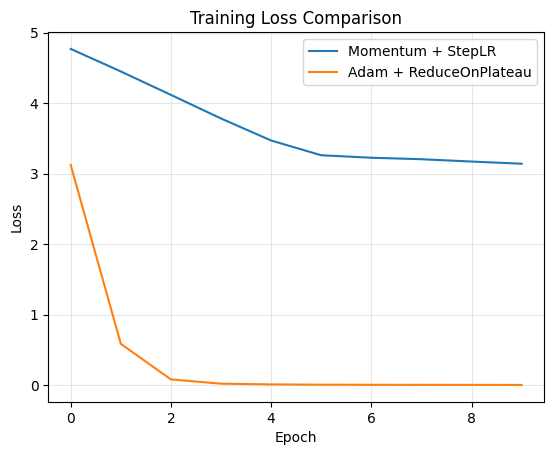

In [12]:
import matplotlib.pyplot as plt

# plot naive loss vs new optim/scheduler
plt.figure()
plt.plot(naive_losses, label='Momentum + StepLR')
plt.plot(new_losses, label='Adam + ReduceOnPlateau')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Comparison')
plt.grid(alpha=0.3)
plt.show()

#### 결과 해석 가이드

위 그래프를 보고 다음 질문에 답해보세요:

**1. 수렴 속도:**
- 어느 조합이 초반(1~3 epoch)에 더 빠르게 loss를 감소시켰나요?
- 이유는 무엇일까요? (Optimizer의 특성, Scheduler의 역할 고려)

**2. 최종 성능:**
- 10 epoch 후 최종 loss가 더 낮은 조합은 무엇인가요?
- Test accuracy와 비교했을 때 일관성이 있나요?

**3. 학습 안정성:**
- Loss 곡선이 부드러운가, 진동이 큰가?
- 진동이 크다면 무엇을 의미하나요? (과적합, 학습률 과다 등)

**4. 실무 적용:**
- 이 실험 결과를 바탕으로, 새로운 데이터셋에서 전이 학습을 할 때 어떤 조합을 먼저 시도할 것인가요?
- 그 이유는 무엇인가요?

## 학생용 자가 체크리스트

- [ ] **전이 학습 개념 이해**: Backbone과 Head의 역할, 레이어 동결의 의미, Partial Fine-tuning의 의도를 명확히 설명할 수 있다.
- [ ] **전이 학습 적용 주의사항**: 데이터 크기, 도메인 차이, 학습률 설정이 전이 학습 성능에 미치는 영향을 이해하고 적절한 전략을 선택할 수 있다.
- [ ] **Optimizer 비교**: SGD+Momentum과 Adam의 작동 원리와 장단점을 설명하고, 상황에 맞게 선택할 수 있다.
- [ ] **Scheduler 비교**: StepLR과 ReduceLROnPlateau의 차이를 이해하고, 각각의 적합한 사용 사례를 설명할 수 있다.
- [ ] **실험 결과 분석**: 학습 곡선을 시각화하고, 가설-결과-해석 구조로 하이퍼파라미터 변경의 효과를 분석할 수 있다.
- [ ] **전체 파이프라인 통합**: **[데이터 준비 → 모델 수정 → 레이어 동결 → 학습 → 성능 비교 → 결과 해석]**으로 이어지는 전이 학습 전체 과정을 독립적으로 수행할 수 있다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.